<a href="https://colab.research.google.com/github/Nalla767/ml/blob/main/loan_approval_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data.csv


In [3]:
df = pd.read_csv("loan_data.csv")
df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


In [4]:
df.shape

(24000, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  object 
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  object 
 6   Approval           24000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


In [6]:
df.isnull().sum()

,0
Text,0
Income,0
Credit_Score,0
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Approval'].value_counts()

,count
Approval,
Rejected,20067
Approved,3933


In [9]:
df.describe()

,Income,Credit_Score,Loan_Amount,DTI_Ratio
count,24000.000000,24000.000000,24000.000000,24000.000000
mean,110377.552708,575.720333,44356.154833,34.719167
std,51729.677627,159.227621,34666.604785,32.322471
min,20001.000000,300.000000,1005.000000,2.530000
25%,65635.750000,437.000000,16212.000000,14.507500
50%,110464.000000,575.000000,35207.000000,24.860000
75%,155187.000000,715.000000,65622.750000,41.840000
max,200000.000000,850.000000,158834.000000,246.330000


In [10]:
df['Employment_Status'].value_counts()

,count
Employment_Status,
unemployed,12007
employed,11993


In [11]:
df['Approval'] = df['Approval'].map({'Approved': 1, 'Rejected': 0})
df['Approval'].value_counts()

,count
Approval,
0,20067
1,3933


In [13]:
X = df[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status']]
y = df['Approval']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
num_cols = ['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']
cat_cols = ['Employment_Status']

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [19]:
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.995417,0.979925,0.992376,0.986111
1,Decision Tree,0.993542,0.974874,0.986023,0.980417
3,Gradient Boosting,0.992083,0.962917,0.989835,0.976190
0,Logistic Regression,0.901875,0.633446,0.952986,0.761035


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_estimators=200
    ))
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Credit_Score',
                                                   'Loan_Amount',
                                                   'DTI_Ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Employment_Status'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4013
           1       0.98      0.99      0.99       787

    accuracy                           1.00      4800
   macro avg       0.99      1.00      0.99      4800
weighted avg       1.00      1.00      1.00      4800

[[3999   14]
 [   5  782]]


In [22]:
y_prob = final_model.predict_proba(X_test)[:, 1]
y_prob[:10]

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.005, 0.   , 1.   ,
       0.   ])

**Sample input**

In [23]:
sample = pd.DataFrame([{
    'Income': 65000,
    'Credit_Score': 720,
    'Loan_Amount': 200000,
    'DTI_Ratio': 28.5,
    'Employment_Status': 'employed'
}])

prediction = final_model.predict(sample)[0]
probability = final_model.predict_proba(sample)[0][1]

print("Prediction:", "Approved" if prediction == 1 else "Rejected")
print("Approval Probability:", round(probability * 100, 2), "%")

Prediction: Rejected
Approval Probability: 0.5 %


In [24]:
import joblib
joblib.dump(final_model, 'loan_approval_pipeline.joblib')

['loan_approval_pipeline.joblib']

1. Improve sample testing
2. Add risk level logic

In [25]:
samples = pd.DataFrame([
    {
        'Income': 65000,
        'Credit_Score': 720,
        'Loan_Amount': 200000,
        'DTI_Ratio': 28.5,
        'Employment_Status': 'employed'
    },
    {
        'Income': 150000,
        'Credit_Score': 810,
        'Loan_Amount': 100000,
        'DTI_Ratio': 12.0,
        'Employment_Status': 'employed'
    },
    {
        'Income': 30000,
        'Credit_Score': 420,
        'Loan_Amount': 250000,
        'DTI_Ratio': 65.0,
        'Employment_Status': 'unemployed'
    }
])

predictions = final_model.predict(samples)
probabilities = final_model.predict_proba(samples)[:, 1]

for i in range(len(samples)):
    print(f"Sample {i+1}")
    print("Prediction:", "Approved" if predictions[i] == 1 else "Rejected")
    print("Approval Probability:", round(probabilities[i] * 100, 2), "%")
    print("-" * 40)

Sample 1
Prediction: Rejected
Approval Probability: 0.5 %
----------------------------------------
Sample 2
Prediction: Rejected
Approval Probability: 3.5 %
----------------------------------------
Sample 3
Prediction: Rejected
Approval Probability: 0.0 %
----------------------------------------


Add risk level logic

In [27]:
def get_risk_level(prob):
    if prob >= 0.75:
        return "Low Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "High Risk"

In [28]:
for i in range(len(samples)):
    risk = get_risk_level(probabilities[i])
    print(f"Sample {i+1}: {risk}")

Sample 1: High Risk
Sample 2: High Risk
Sample 3: High Risk


Get feature importance

In [29]:
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
1,num__Credit_Score,0.339795
4,cat__Employment_Status_employed,0.227898
5,cat__Employment_Status_unemployed,0.190111
3,num__DTI_Ratio,0.115342
2,num__Loan_Amount,0.077639
0,num__Income,0.049216


In [30]:
feature_importance_df.head(10)

,Feature,Importance
1,num__Credit_Score,0.339795
4,cat__Employment_Status_employed,0.227898
5,cat__Employment_Status_unemployed,0.190111
3,num__DTI_Ratio,0.115342
2,num__Loan_Amount,0.077639
0,num__Income,0.049216


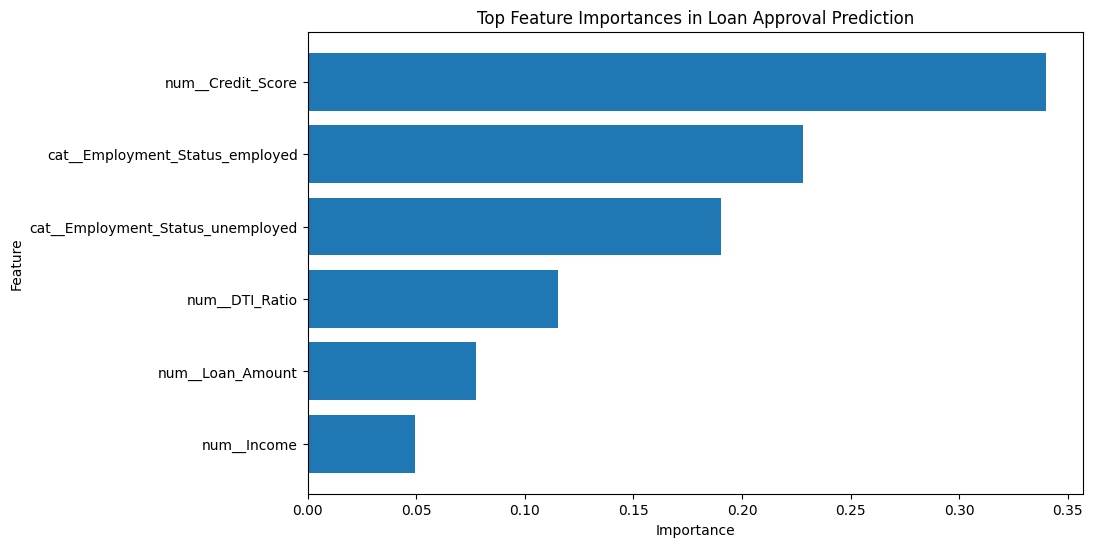

In [31]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances in Loan Approval Prediction")
plt.show()

In [32]:
from google.colab import files
files.download('loan_approval_pipeline.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>